In [7]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv('/content/Dataset .csv')

In [9]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [10]:
df['Rating text'].value_counts()

,count
Rating text,
Average,1574
Good,1152
Not rated,706
Very Good,700
Excellent,205
Poor,73


In [11]:
for col in df.columns:
  print(col)
  print(df[col].nunique())
  print()

Restaurant ID
4411

Restaurant Name
3676

Country Code
8

City
110

Address
4137

Locality
743

Locality Verbose
766

Longitude
3786

Latitude
4041

Cuisines
1214

Average Cost for two
97

Currency
5

Has Table booking
2

Has Online delivery
2

Is delivering now
2

Switch to order menu
1

Price range
4

Aggregate rating
33

Rating color
6

Rating text
6

Votes
869



In [12]:
df = df.drop(columns=[
    'Restaurant ID', 'Restaurant Name', 'Address',
    'Locality', 'Locality Verbose', 'Rating color', 'Rating text',
    'Switch to order menu'
])


In [13]:
df = df.dropna()

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Country Code', 'City', 'Cuisines', 'Currency',
                    'Has Table booking', 'Has Online delivery',
                    'Is delivering now']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [15]:
X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 0.10
R² Score: 0.95


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print("Gradient Boosting:")
print("MSE:", mean_squared_error(y_test, y_pred_gbr))
print("R2 Score:", r2_score(y_test, y_pred_gbr))

Gradient Boosting:
MSE: 0.09473315548681528
R2 Score: 0.9469045322354063


In [20]:
from sklearn.ensemble import AdaBoostRegressor

abr = AdaBoostRegressor(random_state=42)
abr.fit(X_train, y_train)

y_pred_abr = abr.predict(X_test)

print("AdaBoost:")
print("MSE:", mean_squared_error(y_test, y_pred_abr))
print("R2 Score:", r2_score(y_test, y_pred_abr))

AdaBoost:
MSE: 0.13873165608576585
R2 Score: 0.9222445179221791


In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost:
MSE: 0.09626129657709938
R2 Score: 0.9460480489315198


In [23]:
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Define base models
voting = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(random_state=42)),
    ('gbr', GradientBoostingRegressor(random_state=42)),
    ('xgb', XGBRegressor(random_state=42))
])

voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print("Voting Regressor:")
print("MSE:", mean_squared_error(y_test, y_pred_vote))
print("R2 Score:", r2_score(y_test, y_pred_vote))

Voting Regressor:
MSE: 0.08832064761160911
R2 Score: 0.950498575983116


In [24]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Define base models and meta-model
stacking = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gbr', GradientBoostingRegressor(random_state=42)),
        ('xgb', XGBRegressor(random_state=42))
    ],
    final_estimator=RidgeCV()
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print("Stacking Regressor:")
print("MSE:", mean_squared_error(y_test, y_pred_stack))
print("R2 Score:", r2_score(y_test, y_pred_stack))


Stacking Regressor:
MSE: 0.08840142628601462
R2 Score: 0.9504533016387651


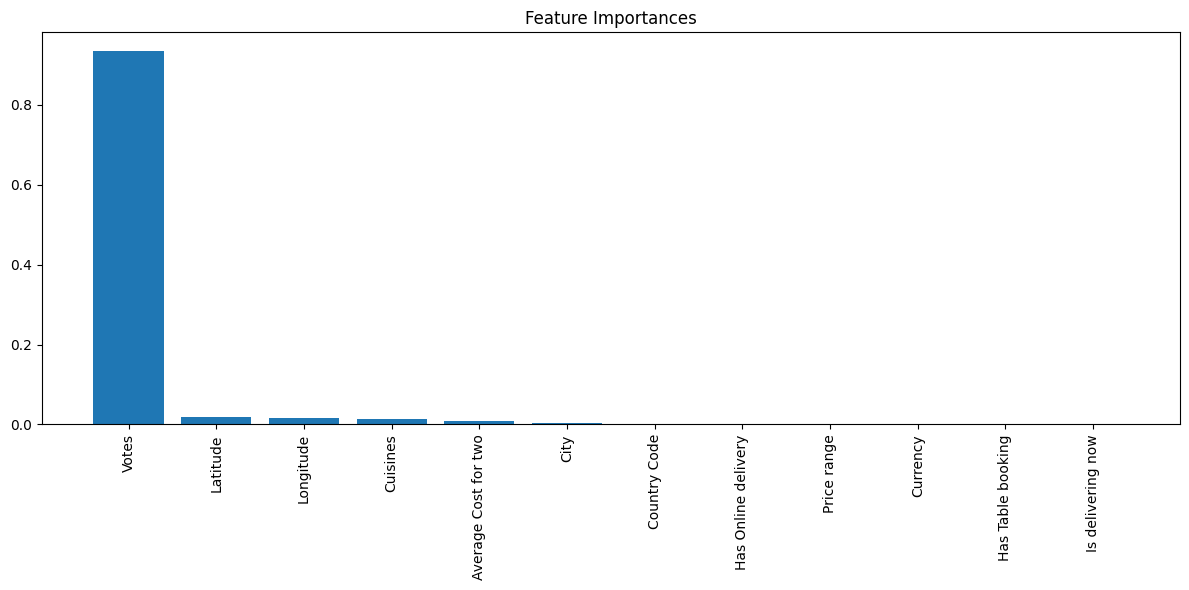

In [25]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
features = X.columns

# Plot
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()